In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import logging
import h5py
import matplotlib.pyplot as plt  # type: ignore
import numpy as np
import healpy as hp
from itertools import product

from mlpng.utils import *
from mlpng.generator import Generator
from mlpng.utils.utils import *
from mlpng.utils.plots import plot_cl, plot_map, plot_map_alm

import lenspyx
from lenspyx import utils_hp

mpi_comm = None

In [ ]:
generator = Generator(
    [
        "settings/n128.json",
        "--nsims",
        "1",
        "--pols",
        "T",
        "--phi_scale",
        "2.0",
        "--shape",
        "local",
        "--no-noise",
        # "--double_precision",
    ]
)

# Get the unlensed gaussian Alms

This should be correct, notice we do not do any non-gaussian here due to just testing the lensing deflection field.

In [ ]:
pol_idxs = generator.pol_idxs()

sims = [
    hp.synalm(generator.c_ell, lmax=generator.lmax, new=True)
    for _ in range(generator.nsims)
]
sims = remove_mono_dipole(np.array(sims))
alm_l = np.ascontiguousarray(sims)[0, 0]  # ensure contiguous memory

plot_cl_alm(
    generator,
    alm_l,
    title=r"Unlensed gaussian $C_{\ell}^{TT}$",
    ylabel=r"$C_{\ell}^{TT}$",
    show=True,
    plot_camb=True,
)
plot_map_alm(
    generator,
    alm_l,
    title=r"Unlensed gaussian $C_{\ell}^{TT}$",
    zoom=True,
    show=True,
)

# Deflection Fields

Here we generate the deflection fields $d_{\ell m}$ for the lensing. We get the lensing potential power spectrum $C_{\ell}^{\phi\phi}$ from CAMB, and convert this to the deflection field by $d_{\ell m} = \sqrt{\ell(\ell+1)}C_{\ell}^{\phi\phi}$. This is per the lenspyx demo https://github.com/carronj/lenspyx/blob/master/examples/demo_lenspyx.ipynb , but I would appricate confirmation that the $C_{\ell}^{\phi\phi}$ is the correct one to use here.

To scale the lensing potential I am currently applying the scale to the $p_{lm}$ before converting to the harmoincs. This is disable right now as I am testing just a normal lensing potential, but does that look correct?

In [ ]:
# we use a buffer for the lmax to ensure we can compute the lensing potential without error
lmax = generator.lmax + generator.lmax_buffer

# our conversion factor = sqrt(l * (l + 1))
fl = np.sqrt(np.arange(lmax + 1) * np.arange(1, lmax + 2))

# cl_phi is PP PT PE, we only want the phi phi part
cl_phi = generator.cosmo._camb_data.get_lens_potential_cls(
    lmax,
    "muK",
    raw_cl=True,
)
cl_phi = cl_phi[..., 0]

# the weird factors here are to match plots from lewis
# https://indico.cern.ch/event/218615/contributions/448794/attachments/353290/492159/Lewis.pdf page 11
plot_cl(
    generator,
    cl_phi * fl**4 / 2 / np.pi,
    title=r"Lensing potential $C_{\ell}^{\phi\phi}$",
    ylabel=r"$(\ell (\ell + 1))^2 / 2 \pi\;C_{\ell}^{\phi\phi}$",
    show=True,
    scale=False,
    plot_func=plt.loglog,
)


In [ ]:
alm_phi = hp.synalm(
    cl_phi,
    lmax,
    lmax,
    new=True,
    verbose=False,
)
alm_phi *= generator.phi_scale  # scale the lensing potential by phi_scale

plot_cl_alm(
    generator,
    alm_phi,
    title="Lensing potential alm, $\phi_{lm}$",
    ylabel=r"$\phi_{lm}$",
    show=True,
    # scale=False,
    plot_func=plt.loglog,
)
plot_map_alm(generator, alm_phi, title="plm", zoom=True, show=True)


In [ ]:
# transform the lensing potential into spin-1 deflection field
dlm = hp.almxfl(alm_phi, fl)

plot_cl_alm(
    generator,
    dlm,
    lmax=lmax,
    title="Lensing deflection field alm",
    ylabel=r"$d_{lm}$",
    # scale=False
    show=True,
    plot_func=plt.loglog,
)
plot_map_alm(generator, dlm, title="$d_{lm}$", zoom=True, show=True)

here we get the lensed maps from the gaussian alm's using our $d_{lm}$s calculated previously. We only do a single T mode lenmap no matter the settings above for testing, this gives us the `alm_l[0, 0]` below which is dimensions `(sim, pol, data)`.

In [ ]:
lenmap = lenspyx.alm2lenmap(
    alm_l,
    dlm,
    geometry=("healpix", {"nside": generator.nside}),
    nthreads=generator.slurm.n_cpus,
)
lenmap = remove_mono_dipole(lenmap)

plot_map(lenmap, title="Lensed map", zoom=True, show=True)

In [ ]:
unlen_map = hp.alm2map(
    alm_l,
    nside=generator.nside,
    lmax=generator.lmax,
    verbose=False,
)
unlen_map = remove_mono_dipole(unlen_map)

plot_map(unlen_map, title="Unlensed map", zoom=True, show=True)
plot_map(lenmap - unlen_map, title="Lensed - Unlensed map", zoom=True, show=True)

Here is where we caculate the error in our estimator for the lenses code. To get the $C_{\ell}$ used to get the $\text{icov}=C^{-1}$ used in the calculation I am using the lensed maps and using anafast to calculate the cls. With many maps I would average over the resulting cls. The issues here is a higher lensing potential will result in a lower variance which is not what we expect.

In [ ]:
cl_lens = hp.anafast(lenmap, use_pixel_weights=True)
cl_lens[:2] = 0

plot_cl(generator, cl_lens, title="Lensed C_l", show=True, plot_camb=True)

plot_cl_vs(
    generator,
    generator.c_ell[0],
    cl_lens,
    title="Lensed vs Unlensed C_l",
    ylabel=r"$C_{\ell}^{TT}$",
    show=True,
    # scale=False,
    # plot_func=plt.plot,
)

plot_cl(
    generator,
    cl_lens / generator.c_ell,
    title="Lensed C_l / Unlensed C_l",
    ylabel=r"$\frac{C_{\ell}^{TT}}{C_{\ell}^{TT,unlensed}}$",
    show=True,
    scale=False,
    plot_func=plt.plot,
)

plot_cl(
    generator,
    (cl_lens - generator.c_ell) / generator.c_ell,
    title="(Lensed - Unlensed C_l) / Unlensed C_l",
    ylabel=r"$\frac{C_{\ell}^{TT} - C_{\ell}^{TT,unlensed}}{C_{\ell}^{TT,unlensed}}$",
    show=True,
    scale=False,
    plot_func=plt.plot,
)

# Compute the fishers

Here we compute the fishers, this takes a very long time based on the nside used

In [ ]:
fisher_mat = np.array(generator.compute_fisher_shapes(generator.shapes))
if len(generator.shapes) > 1:
    marg_likes = np.sqrt(np.diag(np.linalg.inv(fisher_mat)))
else:
    marg_likes = np.sqrt(1 / fisher_mat)

print(f"Unlensed marginal likelihoods: {marg_likes}")

In [ ]:
lens_cls = generator.cosmo.c_ell["lensed_scalar"]["c_ell"][: generator.nell, 0]
lens_cls *= generator.phi_scale

plot_cl_vs(generator, lens_cls, cl_lens, labels=["camb", "lens"], show=True)

In [ ]:
icov = 1 / lens_cls
icov[: generator.lmin] = 0.0
icov = np.array(icov)

fisher_mat = generator.compute_fisher_shapes(generator.shapes, icov=icov)
if len(generator.shapes) > 1:
    marg_likes_lens = np.sqrt(np.diag(np.linalg.inv(fisher_mat)))
else:
    marg_likes_lens = np.sqrt(1 / fisher_mat)

print(f"Marginal likelihoods: {marg_likes_lens}")
print(f"diff: {marg_likes_lens - marg_likes}")

In [ ]:
diff = marg_likes_lens - marg_likes
ratio = marg_likes_lens / marg_likes

print("nside:", generator.nside)
print(
    f"| {generator.phi_scale} | {float(marg_likes)} | {float(marg_likes_lens)} | {float(diff)} | {float(ratio)} |"
)

# the big loop

Just do a big loop to get a table, will take a long time

In [ ]:
# # disable a root logger error from CAMB
# logging.getLogger("root").setLevel(logging.ERROR)

# for phi in [1.0, 1.1, 2, 3, 5, 10, 30, 100]:
#     generator = Generator(
#         [
#             "settings/n64.json",
#             "--nsims",
#             "1",
#             "--pols",
#             "T",
#             "--phi_scale",
#             str(phi),
#             "--shape",
#             "local",
#             "--no-noise",
#             # "--double_precision",
#         ],
#         logging.ERROR,
#     )

#     pol_idxs = generator.pol_idxs()

#     sims = [
#         hp.synalm(generator.c_ell, lmax=generator.lmax, new=True)
#         for _ in range(generator.nsims)
#     ]
#     sims = remove_mono_dipole(np.array(sims))
#     alm_l = np.ascontiguousarray(sims)[0, 0]  # ensure contiguous memory

#     # we use a buffer for the lmax to ensure we can compute the lensing potential without error
#     lmax = generator.lmax + generator.lmax_buffer

#     # our conversion factor = sqrt(l * (l + 1))
#     fl = np.sqrt(np.arange(lmax + 1) * np.arange(1, lmax + 2))

#     # cl_phi is PP PT PE, we only want the phi phi part
#     cl_phi = generator.cosmo._camb_data.get_lens_potential_cls(
#         lmax,
#         "muK",
#         raw_cl=True,
#     )
#     cl_phi = cl_phi[..., 0]

#     alm_phi = hp.synalm(
#         cl_phi,
#         lmax,
#         lmax,
#         new=True,
#         verbose=False,
#     )
#     alm_phi *= generator.phi_scale  # scale the lensing potential by phi_scale

#     dlm = hp.almxfl(alm_phi, fl)

#     lenmap = lenspyx.alm2lenmap(
#         alm_l,
#         dlm,
#         geometry=("healpix", {"nside": generator.nside}),
#         nthreads=generator.slurm.n_cpus,
#     )
#     lenmap = remove_mono_dipole(lenmap)

#     lens_cls = generator.cosmo.c_ell["lensed_scalar"]["c_ell"][: generator.nell, 0]
#     # lens_cls *= generator.phi_scale

#     icov = 1 / lens_cls
#     icov[: generator.lmin] = 0.0
#     icov = np.array(icov)

#     fisher_mat = np.array(generator.compute_fisher_shapes(generator.shapes))
#     if len(generator.shapes) > 1:
#         marg_likes = np.sqrt(np.diag(np.linalg.inv(fisher_mat)))
#     else:
#         marg_likes = np.sqrt(1 / fisher_mat)

#     fisher_mat = generator.compute_fisher_shapes(generator.shapes, icov=icov)
#     if len(generator.shapes) > 1:
#         marg_likes_lens = np.sqrt(np.diag(np.linalg.inv(fisher_mat)))
#     else:
#         marg_likes_lens = np.sqrt(1 / fisher_mat)

#     diff = marg_likes_lens - marg_likes
#     ratio = marg_likes_lens / marg_likes

#     print(
#         f"| {generator.phi_scale} | {float(marg_likes)} | {float(marg_likes_lens)} | {float(diff)} | {float(ratio)} |"
#     )


# S/N test

We will determine the effects of gravitational lensing by calculating the reduction in the
estimator signal to noise when the weights derived by ignoring gravitational lensing are used.
This means that the weight defined in Eq. (25, W(l_1, l_2, l_3)) will always be evaluated using unlensed CMB
power spectra.

however the Gaussian and non-Gaussian six-point functions in Eqs. (24, <N^2>),
(28, delta<N^2>) will be evaluated with the lensed CMB power spectra when specified

In [ ]:
generator = Generator(
    [
        "settings/n128.json",
        "--nsims",
        "1",
        "--pols",
        "T",
        "--phi_scale",
        "2.0",
        "--shape",
        "local",
    ]
)

In [ ]:
# Get B(l_1, l_2, l_3)
B = np.ones((generator.nell, generator.nell, generator.nell))  # just for now

# B(k1, k2, k3)  = 2 * fNL * A_phi^2 * f(k1, k2, k3).
# Create l arrays
l_vals = np.arange(generator.nell)

# Avoid division by zero for l=0
l_factor = np.where(l_vals == 0, 0, 1.0 / (l_vals * (l_vals + 1)))

# Create 3D arrays for the bispectrum calculation
l1_grid, l2_grid, l3_grid = np.meshgrid(l_vals, l_vals, l_vals, indexing="ij")

# Local bispectrum template function
f_local = (
    np.where(l1_grid == 0, 0, 1.0 / (l1_grid * (l1_grid + 1)))
    + np.where(l2_grid == 0, 0, 1.0 / (l2_grid * (l2_grid + 1)))
    + np.where(l3_grid == 0, 0, 1.0 / (l3_grid * (l3_grid + 1)))
)

Pk = generator.cosmo.camb_params.primordial_power(generator.cosmo.transfer["k"], 0)
A = 2 * np.pi**2 * Pk * (3 / 5) ** 2

# Full bispectrum
fNL = 1
B = 2 * fNL * A * f_local

In [ ]:
# W(l_1, l_2, l_3) = (2 pi)^2 delta^(2)(l_1 + l_2 + l_3) B(l_1, l_2, l_3) / (6 * C_l1 C_l2 C_l3)


c_ell = generator.c_ell[0]
cl6 = 6 * c_ell[:, None, None] * c_ell[None, :, None] * c_ell[None, None, :]

Ws = (2 * np.pi) ** 2 * B / cl6

l1_grid, l2_grid, l3_grid = np.meshgrid(
    np.arange(generator.nell),
    np.arange(generator.nell),
    np.arange(generator.nell),
    indexing="ij",
)

# Triangle inequality constraints
triangle_condition = (
    (np.abs(l1_grid - l2_grid) <= l3_grid)
    & (l3_grid <= l1_grid + l2_grid)
    & (np.abs(l1_grid - l3_grid) <= l2_grid)
    & (l2_grid <= l1_grid + l3_grid)
    & (np.abs(l2_grid - l3_grid) <= l1_grid)
    & (l1_grid <= l2_grid + l3_grid)
)

# Parity constraint: l1 + l2 + l3 must be even
parity_condition = (l1_grid + l2_grid + l3_grid) % 2 == 0

# Combine all constraints
valid_triangles = triangle_condition & parity_condition

Ws = np.where(
    valid_triangles,
    (2 * np.pi) ** 2 * B / cl6,
    0.0,  # Set invalid triangles to zero
)


In [ ]:
# <S> = int d^2 l_1 / (2 pi)^2 l_2 / (2 pi)^2 l_3 / (2 pi)^2 W(l_1, l_2, l_3) (2 pi) ^2 delta^(2)(l_1+l_2+l_3)B(l1, l2, l3)

# l = 2 pi / L n, so int d^2 l / (2 pi)^2  -> 1 / (2 pi)^2 sum_l
S_avg = np.sum(Ws * B) / (2 * np.pi) ** 2

In [ ]:
# <N^2> = int d^2 l_1 / (2 pi)^2 l_2 / (2 pi)^2 l_3 / (2 pi)^2 W^2(l_1, l_2, l_3) 6 * C_l1 C_l2 C_l3

# will need lensed and unlensed C_l versions
c_ell = generator.c_ell_lens[0]
cl6_lens = 6 * c_ell[:, None, None] * c_ell[None, :, None] * c_ell[None, None, :]

N2_avg_0 = np.sum(Ws**2 * cl6) / (2 * np.pi) ** 4
N2_avg_lens = np.sum(Ws**2 * cl6_lens) / (2 * np.pi) ** 4


In [ ]:
# delta<N^2> = 9 / (2 pi)^8 int d^2 l_1 d^2 l_2 d^2 l_3 d^2 l'_1 d^2 l'_2 d^2 l'_3 W(l_1, l_2, l_3) W(l'_1, l'_2, l'_3) delta^(2)(l_1 + l'_1) C_l1 delta^(2)(l_2 + l_3 + l'_2 + l'_3) T(l2, l_3, l'_2, l'_3)

In [ ]:
# finally plot S/N vs l_max

# (S/N)^2 = <S>^2 / <N^2>
s_n_0 = S_avg**2 / N2_avg_0
s_n_lens = S_avg**2 / N2_avg_lens

plt.plot(np.arange(generator.n_ell), s_n_lens / s_n_0)

In [ ]:
##### We will determine the effects of gravitational lensing by calculating the reduction in the
# estimator signal to noise when the weights derived by ignoring gravitational lensing are used.
# This means that the weight defined in Eq. (25, W(l_1, l_2, l_3)) will always be evaluated using unlensed CMB
# power spectra.

#### however the Gaussian and non-Gaussian six-point functions in Eqs. (24, <N^2>),
# (28, delta<N^2>) will be evaluated with the lensed CMB power spectra when specified

In [ ]:
# to make fig 5 take the ratio of (S/N)_GL / (S/N)_0 where GL has the lensing applied as above (still no lensing in the W's.)


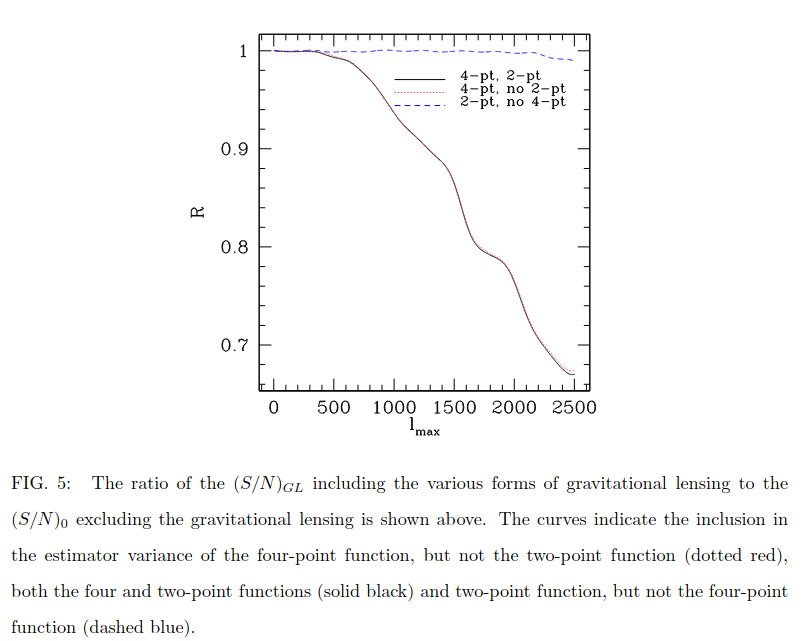